# CNN-based Variational AutoEncoder (VAE) on CIFAR-10

In [ ]:
 %pip install torch torchvision numpy tqdm matplotlib --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


### Mount Google Drive (Required for Checkpoints)
This cell is used to connect to your Google Drive where checkpoints will be saved.

In [ ]:
# =============================================================================
# MOUNT GOOGLE DRIVE 
# =============================================================================
# This connects Colab notebook to Google Drive storage.
# Checkpoints will be saved to: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")
print("Checkpoint save path: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/")

Mounted at /content/drive
Google Drive mounted successfully!
Checkpoint save path: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/


### Summarized Architecture and hyperparameters understanding
| Component | Input | Output | Purpose |
|-----------|-------|--------|---------|
| **Encoder** | 32×32×3 image | μ (128) + σ (128) | Compress to latent space |
| **Reparameterization** | μ, σ | z = μ + σ×ε | Enable backprop through sampling |
| **Decoder** | z (128-dim) | 32×32×3 image | Reconstruct from latent |

### Loss Function
```
Total Loss = BCE(x, x̂) + β × KL(q(z|x) || N(0,1))

Where:
- BCE = Reconstruction loss (how similar is output to input?)
- KL = -½ × Σ(1 + log(σ²) - μ² - σ²)  (how close is q(z|x) to N(0,1)?)
- β = 1 (standard) | β > 1 (more disentangled, blurrier) | β < 1 (sharper, entangled)
```

### Mean (μ) & Variance (σ²)
- **μ (mean)**: "Where" in latent space this image probably is
- **σ (std)**: "How certain" the encoder is about this location
- **Reparameterization trick**: z = μ + σ × ε allows gradients to flow through μ and σ

### Hyperparameters
- **latent_dim**: 128 | **batch_size**: 100 | **epochs**: 100 | **lr**: 1e-3


In [ ]:
import torch
import torch.nn as nn

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid

In [ ]:

# Automatically detect and use CUDA if available, otherwise use CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Model Hyperparameters
dataset_path = './data'  # Path where CIFAR-10 will be downloaded
batch_size = 100
latent_dim = 128  # Dimension of latent space

lr = 1e-3
epochs = 100

Using device: cuda


###    Step 1. Load (or download) Dataset

In [ ]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader


cifar_transform = transforms.Compose([
        transforms.ToTensor(),
])
kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = CIFAR10(dataset_path, transform=cifar_transform, train=True, download=True)
test_dataset  = CIFAR10(dataset_path, transform=cifar_transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False, **kwargs)

100%|██████████| 170M/170M [00:04<00:00, 35.0MB/s]


### Step 2. CNN-based Variational AutoEncoder (VAE) Architecture Definition

In [ ]:
"""
    CNN-based Encoder and Decoder for CIFAR-10
"""

class Encoder(nn.Module):

    def __init__(self, latent_dim):
        super(Encoder, self).__init__()

        # Convolutional layers with more channels
        self.conv1 = nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1)    # 32*32 -> 16*16
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 16*16 -> 8*8
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1) # 8*8 -> 4*4
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1) # 4*4 -> 2*2

        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

        # Fully connected layers for mean and variance
        # After conv4: 512 channels * 2 * 2 spatial = 2048 features
        self.fc_mean = nn.Linear(512 * 2 * 2, latent_dim)
        self.fc_var = nn.Linear(512 * 2 * 2, latent_dim)

        # LeakyReLU allows small negative gradients (better than ReLU)
        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.leaky_relu(self.bn1(self.conv1(x)))
        x = self.leaky_relu(self.bn2(self.conv2(x)))
        x = self.leaky_relu(self.bn3(self.conv3(x)))
        x = self.leaky_relu(self.bn4(self.conv4(x)))

        x = x.view(x.size(0), -1)  # Flatten: (batch, 512, 2, 2) -> (batch, 2048)

        mean = self.fc_mean(x)
        log_var = self.fc_var(x)

        return mean, log_var

In [ ]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()

        # Fully connected layer to expand latent vector
        self.fc = nn.Linear(latent_dim, 512 * 2 * 2)

        # Transposed convolutional layers (matching encoder dimensions)
        self.deconv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)  # 2*2 -> 4*4
        self.deconv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 4*4 -> 8*8
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)   # 8*8 -> 16*16
        self.deconv4 = nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)     # 16*16 -> 32*32

        self.bn1 = nn.BatchNorm2d(256)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(64)

        self.leaky_relu = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), 512, 2, 2)  # Reshape to feature map

        x = self.leaky_relu(self.bn1(self.deconv1(x)))
        x = self.leaky_relu(self.bn2(self.deconv2(x)))
        x = self.leaky_relu(self.bn3(self.deconv3(x)))

        # Sigmoid ensures output is in [0, 1] range (valid pixel values)
        x_hat = torch.sigmoid(self.deconv4(x))

        return x_hat

In [ ]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(DEVICE)      # sampling epsilon
        z = mean + var*epsilon                          # reparameterization trick
        return z


    def forward(self, x):
        mean, log_var = self.Encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) # takes exponential function (log var -> var)
        x_hat = self.Decoder(z)

        return x_hat, mean, log_var

In [ ]:
encoder = Encoder(latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(DEVICE)

# =============================================================================
# Print Model Architecture
# =============================================================================
print("=" * 60)
print("VAE MODEL ARCHITECTURE")
print("=" * 60)

print("\n" + "=" * 60)
print("ENCODER")
print("=" * 60)
print(encoder)

print("\n" + "=" * 60)
print("DECODER")
print("=" * 60)
print(decoder)

print("\n" + "=" * 60)
print("FULL VAE MODEL")
print("=" * 60)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\n" + "=" * 60)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("=" * 60)

VAE MODEL ARCHITECTURE

ENCODER
Encoder(
  (conv1): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_mean): Linear(in_features=2048, out_features=128, bias=True)
  (fc_var): Linear(in_features=2048, out_features=128, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2)
)

DECODER
Decoder(
  (fc): Linear(in_features=128, out_features=2048, bias=True)
  (deconv1): ConvTranspose2

### Step 3.  Loss function and optimizer defintion

In [ ]:
from torch.optim import Adam

def loss_function(x, x_hat, mean, log_var):
    """
    VAE Loss = Reconstruction Loss + KL Divergence

    Using 'sum' reduction for reconstruction loss.
     - Reconstruction Loss (MSE): Measures how well the decoder reconstructs the input.
     - KL Divergence: Regularizes the latent space to follow a standard normal distribution.
     """
    # MSE loss is better for continuous pixel values
   
    reconstruction_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')

    # KL Divergence with sum reduction
    # Measures how close q(z|x) is to N(0,1)
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    # When both reconstruction and KL terms are summed, a kl_weight (beta) of 1.0 is often used
    # for a standard VAE, as it directly balances the two components.
    # Overall average loss per batch is then handled by the training loop.

    return reconstruction_loss + KLD


optimizer = Adam(model.parameters(), lr=lr)

### Checkpoint Utilities written for collab

This section contains all checkpoint-related functions in one place:
1. **Saving utilities** - Functions to save best, periodic, and final models
2. **Loading utilities** - Functions to resume training after Colab timeout

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# =============================================================================
# CHECKPOINT CONFIGURATION
# =============================================================================
# Change checkpoint_dir to your Google Drive path
checkpoint_dir = '/content/drive/MyDrive/VAE_CIFAR10_Checkpoints'

# Note: EVERY epoch information has been recorded for zero data loss due to Colab timeouts. 
# It can be safely stopped and restarted without losing progress.
# Each epoch saves: train_losses.npy (~4KB) + checkpoint_epoch_XXX.pt (~40MB)

# =============================================================================
# CHECKPOINT SAVING FUNCTIONS
# =============================================================================

def setup_checkpoint_dir(checkpoint_dir):
    """Create checkpoint directory and return run_dir with unique timestamp."""
    os.makedirs(checkpoint_dir, exist_ok=True)
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(checkpoint_dir, f'run_{run_id}')
    os.makedirs(run_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {run_dir}")
    return run_dir, run_id


def save_epoch_losses(train_losses, run_dir):
    """
    Save losses to disk EVERY epoch .
    This ensures your plot is always honest - no data loss even if Colab crashes!
    """
    np.save(os.path.join(run_dir, 'train_losses.npy'), np.array(train_losses))


def save_best_model(model, optimizer, epoch, loss, hyperparams, run_dir):
    """Save the best model checkpoint (overwrites previous best)."""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'hyperparameters': hyperparams
    }
    torch.save(checkpoint, os.path.join(run_dir, 'best_model.pt'))


def save_periodic_checkpoint(model, optimizer, epoch, loss, train_losses, hyperparams, run_dir):
    """
    Save full checkpoint EVERY epoch for 100% crash recovery.
    Contains: model weights, optimizer state, loss history, hyperparameters.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'train_losses': train_losses.copy(),
        'hyperparameters': hyperparams
    }
    torch.save(checkpoint, os.path.join(run_dir, f'checkpoint_epoch_{epoch:03d}.pt'))


def save_final_model(model, encoder, decoder, optimizer, epochs, train_losses, training_history, run_dir):
    """Save complete final model with all training history."""
    checkpoint = {
        'epoch': epochs,
        'model_state_dict': model.state_dict(),
        'encoder_state_dict': encoder.state_dict(),
        'decoder_state_dict': decoder.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': train_losses[-1],
        'train_losses': train_losses,
        'training_history': training_history
    }
    torch.save(checkpoint, os.path.join(run_dir, 'final_model.pt'))
    # Final save of losses (redundant but ensures consistency)
    np.save(os.path.join(run_dir, 'train_losses.npy'), np.array(train_losses))


def save_training_curve(train_losses, best_loss, best_epoch, epochs, run_dir):
    """Plot and save training loss curve."""
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-', linewidth=2, marker='o', markersize=4)
    plt.axhline(y=best_loss, color='r', linestyle='--', label=f'Best: {best_loss:.4f} (Epoch {best_epoch})')
    plt.scatter([best_epoch], [best_loss], color='red', s=100, zorder=5, edgecolors='black')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Average Loss', fontsize=12)
    plt.title('VAE Training Curve', fontsize=14)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'training_curve.png'), dpi=150)
    plt.show()


# =============================================================================
# CHECKPOINT LOADING FUNCTIONS (For Colab Timeout Recovery)
# =============================================================================

def find_latest_run(checkpoint_dir):
    """Find the most recent training run directory."""
    if not os.path.exists(checkpoint_dir):
        return None
    all_runs = sorted([d for d in os.listdir(checkpoint_dir)
                       if os.path.isdir(os.path.join(checkpoint_dir, d))])
    return os.path.join(checkpoint_dir, all_runs[-1]) if all_runs else None


def load_checkpoint_for_resume(checkpoint_dir, model, optimizer, device):
    """
    Load the latest checkpoint for resuming training after Colab timeout.

    Returns: (start_epoch, train_losses, run_dir) or (0, [], None) if no checkpoint.
    """
    latest_run = find_latest_run(checkpoint_dir)

    if latest_run is None:
        print("No previous runs found. Starting fresh training.")
        return 0, [], None

    # Step 1: Load losses from train_losses.npy (most up-to-date, saved every epoch)
    losses_path = os.path.join(latest_run, 'train_losses.npy')
    if os.path.exists(losses_path):
        saved_losses = np.load(losses_path).tolist()
        losses_epoch = len(saved_losses)
        print(f"Found train_losses.npy with {losses_epoch} epochs of loss data")
    else:
        saved_losses = []
        losses_epoch = 0

    # Step 2: Find the latest epoch checkpoint
    periodic_checkpoints = sorted([f for f in os.listdir(latest_run)
                                   if f.startswith('checkpoint_epoch_') and f.endswith('.pt')])

    if periodic_checkpoints:
        checkpoint_path = os.path.join(latest_run, periodic_checkpoints[-1])
        print(f"Resuming model from checkpoint: {checkpoint_path}")
    elif os.path.exists(os.path.join(latest_run, 'best_model.pt')):
        checkpoint_path = os.path.join(latest_run, 'best_model.pt')
        print(f"Resuming model from best model: {checkpoint_path}")
    else:
        print("No checkpoints found in latest run. Starting fresh training.")
        return 0, [], None

    # Load model and optimizer state
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    checkpoint_epoch = checkpoint['epoch']

    # Use the most complete loss history
    if losses_epoch >= checkpoint_epoch:
        train_losses = saved_losses
        start_epoch = losses_epoch
        print(f"Using loss data from train_losses.npy (epochs 1-{losses_epoch})")
    else:
        train_losses = checkpoint.get('train_losses', saved_losses)
        start_epoch = checkpoint_epoch
        print(f"Using loss data from checkpoint (epochs 1-{checkpoint_epoch})")

    print(f"Will resume training from epoch {start_epoch + 1}, model weights from epoch {checkpoint_epoch}")
    return start_epoch, train_losses, latest_run


def load_best_model_for_inference(checkpoint_dir, model, device):
    """Load the best model for inference/generation (no optimizer needed)."""
    latest_run = find_latest_run(checkpoint_dir)
    if latest_run is None:
        raise FileNotFoundError(f"No training runs found in {checkpoint_dir}")

    best_path = os.path.join(latest_run, 'best_model.pt')
    if not os.path.exists(best_path):
        raise FileNotFoundError(f"best_model.pt not found in {latest_run}")

    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Loaded best model from epoch {checkpoint['epoch']}, loss: {checkpoint['loss']:.4f}")
    return model


print("Checkpoint utilities loaded successfully!")
print("Note: Every epoch saves checkpoint_epoch_XXX.pt (~40MB) + train_losses.npy (~4KB)")
print("      Total storage: ~4GB for 100 epochs | Zero data loss guaranteed!")

Checkpoint utilities loaded successfully!
Note: Every epoch saves checkpoint_epoch_XXX.pt (~40MB) + train_losses.npy (~4KB)
      Total storage: ~4GB for 100 epochs | Zero data loss guaranteed!


### Step 4. Train Variational AutoEncoder (VAE)

Checkpoints will be saved to: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053
Start training VAE...
	Epoch 1/100 | Loss: 100.3260 | *** BEST *** | Checkpoint saved
	Epoch 2/100 | Loss: 82.4601 | *** BEST *** | Checkpoint saved
	Epoch 3/100 | Loss: 79.9675 | *** BEST *** | Checkpoint saved
	Epoch 4/100 | Loss: 79.0087 | *** BEST *** | Checkpoint saved
	Epoch 5/100 | Loss: 78.0066 | *** BEST *** | Checkpoint saved
	Epoch 6/100 | Loss: 77.4338 | *** BEST *** | Checkpoint saved
	Epoch 7/100 | Loss: 77.0279 | *** BEST *** | Checkpoint saved
	Epoch 8/100 | Loss: 76.7024 | *** BEST *** | Checkpoint saved
	Epoch 9/100 | Loss: 76.4527 | *** BEST *** | Checkpoint saved
	Epoch 10/100 | Loss: 76.0858 | *** BEST *** | Checkpoint saved
	Epoch 11/100 | Loss: 76.0272 | *** BEST *** | Checkpoint saved
	Epoch 12/100 | Loss: 75.7937 | *** BEST *** | Checkpoint saved
	Epoch 13/100 | Loss: 75.6396 | *** BEST *** | Checkpoint saved
	Epoch 14/100 | Loss: 75.4795 | *** BEST *** | Checkpoint

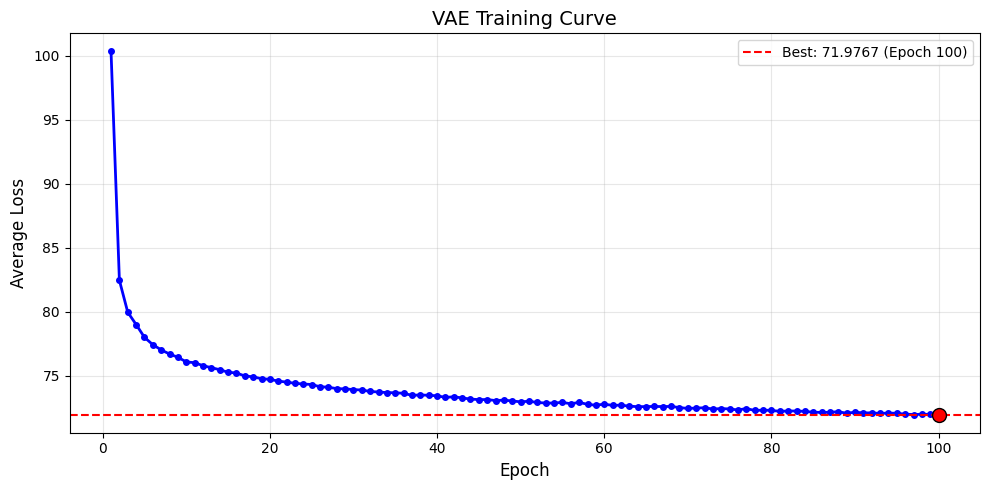


TRAINING COMPLETE!
Best Loss: 71.9767 (Epoch 100)
Checkpoints saved to: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053


In [ ]:
# =============================================================================
# FRESH TRAINING 
# =============================================================================

# Setup checkpoint directory
run_dir, run_id = setup_checkpoint_dir(checkpoint_dir)

# Initialize training history
training_history = {
    'run_id': run_id,
    'hyperparameters': {
        'latent_dim': latent_dim,
        'batch_size': batch_size,
        'learning_rate': lr,
        'epochs': epochs,
        'device': str(DEVICE)
    },
    'losses': [],
    'best_loss': float('inf'),
    'best_epoch': 0
}

# Training loop
print("Start training VAE...")
model.train()
train_losses = []

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(DEVICE)
        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)
        overall_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = overall_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    training_history['losses'].append(avg_loss)

    # =========================================================================
    # SAVE EVERYTHING EVERY EPOCH (Zero Data Loss)
    # =========================================================================

    # 1. ALWAYS save losses (lightweight ~4KB)
    save_epoch_losses(train_losses, run_dir)

    # 2. ALWAYS save full checkpoint with model weights (~40MB)
    save_periodic_checkpoint(model, optimizer, epoch + 1, avg_loss,
                            train_losses, training_history['hyperparameters'], run_dir)

    # 3. ADDITIONALLY save best_model.pt if this is the best epoch
    if avg_loss < training_history['best_loss']:
        training_history['best_loss'] = avg_loss
        training_history['best_epoch'] = epoch + 1
        save_best_model(model, optimizer, epoch + 1, avg_loss,
                       training_history['hyperparameters'], run_dir)
        print(f"\tEpoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | *** BEST *** | Checkpoint saved")
    else:
        print(f"\tEpoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Checkpoint saved")

# Save final model and training curve
save_final_model(model, encoder, decoder, optimizer, epochs, train_losses, training_history, run_dir)
save_training_curve(train_losses, training_history['best_loss'],
                   training_history['best_epoch'], epochs, run_dir)

print("\n" + "=" * 60)
print("TRAINING COMPLETE!")
print(f"Best Loss: {training_history['best_loss']:.4f} (Epoch {training_history['best_epoch']})")
print(f"Checkpoints saved to: {run_dir}")
print("=" * 60)


### Resume Training After Colab Timeout

**Run this cell instead of "Fresh Training" if Colab session timed out.**

It will:
1. Find the latest checkpoint automatically
2. Load model weights and optimizer state
3. Continue training from where it stopped

Found train_losses.npy with 100 epochs of loss data
Resuming model from checkpoint: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053/checkpoint_epoch_100.pt
Using loss data from train_losses.npy (epochs 1-100)
Will resume training from epoch 101, model weights from epoch 100

Resuming training from epoch 101, 0 epochs remaining...


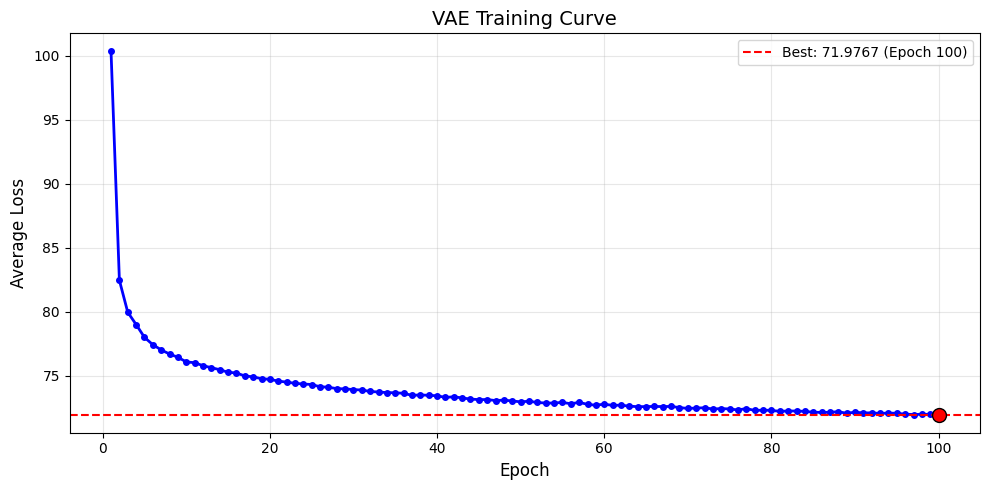


RESUMED TRAINING COMPLETE!
Best Loss: 71.9767 (Epoch 100)
Checkpoints saved to: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053


In [ ]:
# =============================================================================
# RESUME TRAINING AFTER COLAB TIMEOUT
# =============================================================================

# Load checkpoint and get starting point
start_epoch, train_losses, run_dir = load_checkpoint_for_resume(
    checkpoint_dir, model, optimizer, DEVICE
)

if run_dir is None:
    # No previous checkpoint, create new run
    run_dir, run_id = setup_checkpoint_dir(checkpoint_dir)
    start_epoch = 0
    train_losses = []

# Initialize/restore training history
training_history = {
    'run_id': os.path.basename(run_dir),
    'hyperparameters': {
        'latent_dim': latent_dim,
        'batch_size': batch_size,
        'learning_rate': lr,
        'epochs': epochs,
        'device': str(DEVICE)
    },
    'losses': train_losses.copy(),
    'best_loss': min(train_losses) if train_losses else float('inf'),
    'best_epoch': train_losses.index(min(train_losses)) + 1 if train_losses else 0
}

# Continue training from where we left off
remaining_epochs = epochs - start_epoch
print(f"\nResuming training from epoch {start_epoch + 1}, {remaining_epochs} epochs remaining...")
model.train()

for epoch in range(start_epoch, epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(DEVICE)
        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        loss = loss_function(x, x_hat, mean, log_var)
        overall_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = overall_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    training_history['losses'].append(avg_loss)

    # =========================================================================
    # SAVE EVERYTHING EVERY EPOCH (Zero Data Loss)
    # =========================================================================

    # 1. ALWAYS save losses 
    save_epoch_losses(train_losses, run_dir)

    # 2. ALWAYS save full checkpoint with model weights 
    save_periodic_checkpoint(model, optimizer, epoch + 1, avg_loss,
                            train_losses, training_history['hyperparameters'], run_dir)

    # 3. ADDITIONALLY save best_model.pt if this is the best epoch
    if avg_loss < training_history['best_loss']:
        training_history['best_loss'] = avg_loss
        training_history['best_epoch'] = epoch + 1
        save_best_model(model, optimizer, epoch + 1, avg_loss,
                       training_history['hyperparameters'], run_dir)
        print(f"\tEpoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | *** BEST *** | Checkpoint saved")
    else:
        print(f"\tEpoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Checkpoint saved")

# Save final model
save_final_model(model, encoder, decoder, optimizer, epochs, train_losses, training_history, run_dir)
save_training_curve(train_losses, training_history['best_loss'],
                   training_history['best_epoch'], epochs, run_dir)

print("\n" + "=" * 60)
print("RESUMED TRAINING COMPLETE!")
print(f"Best Loss: {training_history['best_loss']:.4f} (Epoch {training_history['best_epoch']})")
print(f"Checkpoints saved to: {run_dir}")
print("=" * 60)

### How to Load and Reuse Saved Checkpoints

Here's  Different types of checkpoints generated during training can be loaded and reused

In [ ]:
# =============================================================================
# LOAD BEST MODEL (for inference):
# Purpose: To load the model with the lowest loss for making predictions.
# =============================================================================

import torch
import os


checkpoint_root = '/content/drive/MyDrive/VAE_CIFAR10_Checkpoints'
all_runs = sorted([d for d in os.listdir(checkpoint_root) if os.path.isdir(os.path.join(checkpoint_root, d))])
if all_runs:
    latest_run_dir = os.path.join(checkpoint_root, all_runs[-1])
    best_model_path = os.path.join(latest_run_dir, 'best_model.pt')

    if os.path.exists(best_model_path):
        print(f"Loading best model from: {best_model_path}")
        checkpoint = torch.load(best_model_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval() # Set the model to evaluation mode
        print("Best model loaded successfully and set to evaluation mode.")
    else:
        print(f"Best model not found at {best_model_path}. Please check the path.")
else:
    print(f"No training runs found in {checkpoint_root}.")

Loading best model from: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053/best_model.pt
Best model loaded successfully and set to evaluation mode.


In [ ]:
# =============================================================================
# RESUME TRAINING (from a periodic checkpoint):
# Purpose: To continue training from a specific point, useful after interruptions.
# =============================================================================

import torch
import os


checkpoint_root = '/content/drive/MyDrive/VAE_CIFAR10_Checkpoints'
all_runs = sorted([d for d in os.listdir(checkpoint_root) if os.path.isdir(os.path.join(checkpoint_root, d))])

if all_runs:
    latest_run_dir = os.path.join(checkpoint_root, all_runs[-1])
    # Find the latest periodic checkpoint in the directory
    periodic_checkpoints = sorted([f for f in os.listdir(latest_run_dir) if f.startswith('checkpoint_epoch_') and f.endswith('.pt')])

    if periodic_checkpoints:
        latest_periodic_checkpoint_path = os.path.join(latest_run_dir, periodic_checkpoints[-1])
        print(f"Resuming training from: {latest_periodic_checkpoint_path}")
        checkpoint = torch.load(latest_periodic_checkpoint_path, map_location=DEVICE)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        train_losses = checkpoint['train_losses']

        print(f"Training resumed from epoch {start_epoch + 1} with last recorded loss {checkpoint['loss']:.4f}.")
        # You can now continue your training loop from start_epoch + 1
    else:
        print(f"No periodic checkpoints found in {latest_run_dir}. Starting training from scratch.")
else:
    print(f"No training runs found in {checkpoint_root}. Starting training from scratch.")

Resuming training from: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053/checkpoint_epoch_100.pt
Training resumed from epoch 101 with last recorded loss 71.9767.


Loading training losses from: /content/drive/MyDrive/VAE_CIFAR10_Checkpoints/run_20260213_092053/train_losses.npy


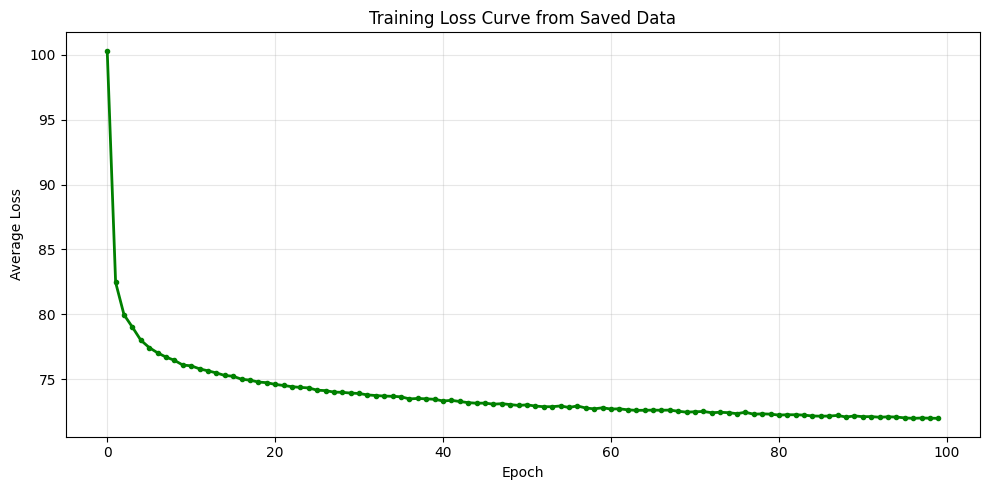

Loss history plotted successfully.


In [ ]:
# =============================================================================
# QUICK LOSS ANALYSIS (without loading model):
# Purpose: To quickly visualize the training loss curve without loading the full model.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import os

checkpoint_root = '/content/drive/MyDrive/VAE_CIFAR10_Checkpoints'
all_runs = sorted([d for d in os.listdir(checkpoint_root) if os.path.isdir(os.path.join(checkpoint_root, d))])

if all_runs:
    latest_run_dir = os.path.join(checkpoint_root, all_runs[-1])
    losses_path = os.path.join(latest_run_dir, 'train_losses.npy')

    if os.path.exists(losses_path):
        print(f"Loading training losses from: {losses_path}")
        losses = np.load(losses_path)

        plt.figure(figsize=(10, 5))
        plt.plot(losses, 'g-', linewidth=2, marker='.', markersize=6)
        plt.title('Training Loss Curve from Saved Data')
        plt.xlabel('Epoch')
        plt.ylabel('Average Loss')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("Loss history plotted successfully.")
    else:
        print(f"Losses file not found at {losses_path}. Please check the path.")
else:
    print(f"No training runs found in {checkpoint_root}.")

### Step 5. Generate images from test dataset

In [ ]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        x = x.to(DEVICE)  # Keep as (batch, 3, 32, 32) for CNN

        x_hat, _, _ = model(x)

        break

  0%|          | 0/100 [00:00<?, ?it/s]


In [ ]:
def show_image(x, idx):
    # x is already (batch, 3, 32, 32) from CNN output
    fig = plt.figure()
    # Transpose from (C, H, W) to (H, W, C) for matplotlib
    img = x[idx].cpu().numpy().transpose(1, 2, 0)
    plt.imshow(np.clip(img, 0, 1))  # Clip values to valid range
    plt.axis('off')

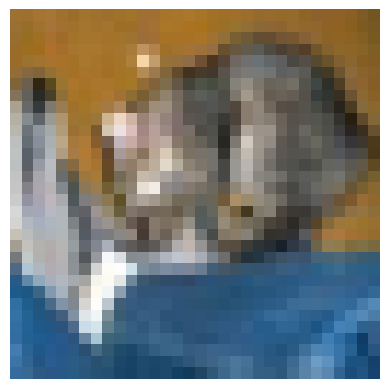

In [ ]:
show_image(x, idx=0)

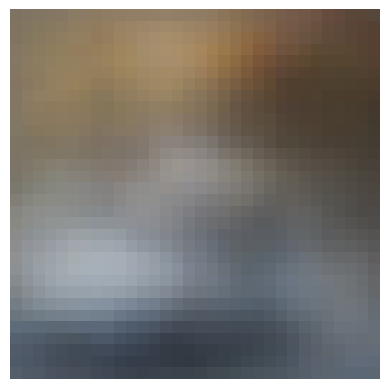

In [ ]:
show_image(x_hat, idx=0)

### Step 6. Generate image from noise vector

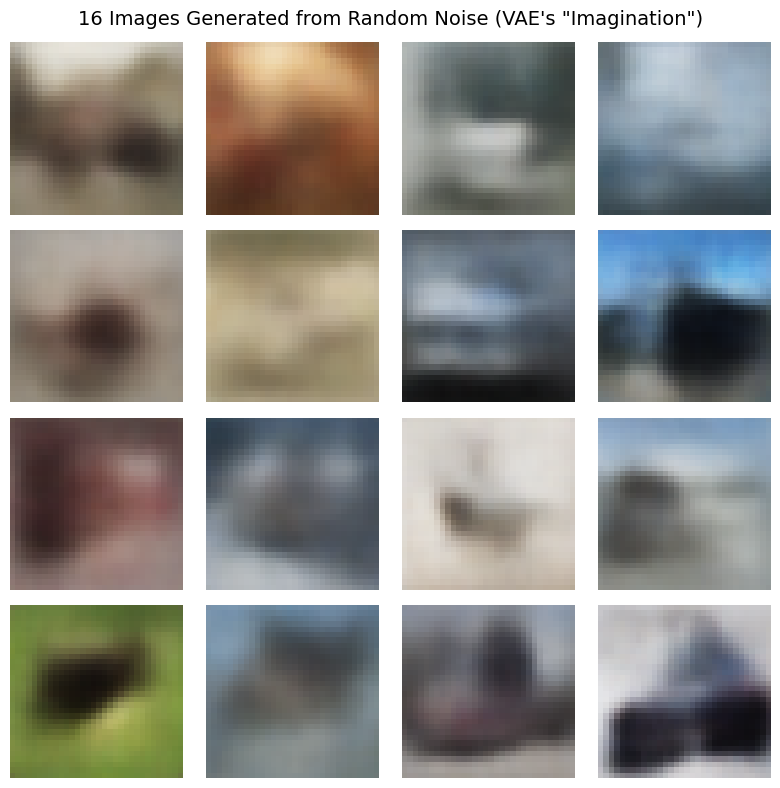

In [ ]:
# Generate images from random noise
with torch.no_grad():
    noise = torch.randn(batch_size, latent_dim).to(DEVICE)
    generated_images = decoder(noise)

# =============================================================================
# Display a 4x4 Grid of 16 Generated Images
# =============================================================================
# These images are "dreamed up" by the model from pure random noise
# =============================================================================

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.suptitle('16 Images Generated from Random Noise (VAE\'s "Imagination")', fontsize=14)

for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        img = generated_images[idx].cpu().numpy().transpose(1, 2, 0)
        axes[i, j].imshow(np.clip(img, 0, 1))
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

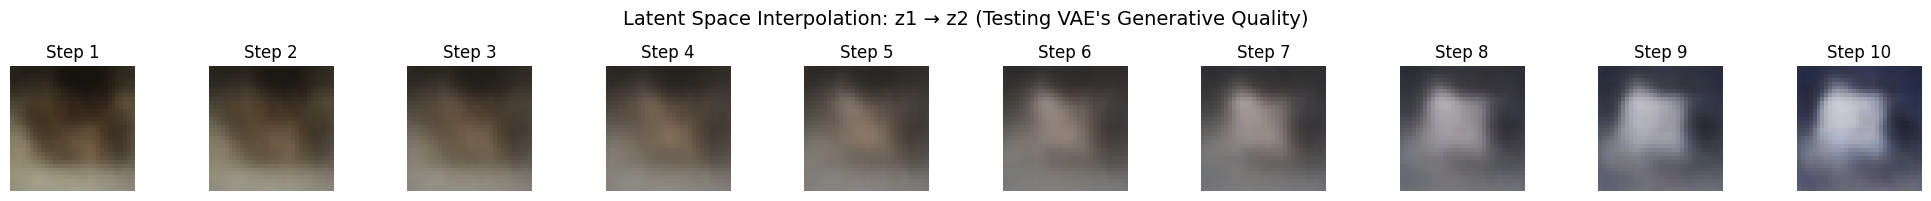

EXPERIMENT: Comparing β=1 vs β=5
Training β-VAE with β=1...
  Epoch 1/50, Avg Loss: 99.15
  Epoch 2/50, Avg Loss: 82.46
  Epoch 3/50, Avg Loss: 80.06
  Epoch 4/50, Avg Loss: 79.01
  Epoch 5/50, Avg Loss: 78.05
  Epoch 6/50, Avg Loss: 77.45
  Epoch 7/50, Avg Loss: 77.04
  Epoch 8/50, Avg Loss: 76.78
  Epoch 9/50, Avg Loss: 76.39
  Epoch 10/50, Avg Loss: 76.16
  Epoch 11/50, Avg Loss: 75.87
  Epoch 12/50, Avg Loss: 75.73
  Epoch 13/50, Avg Loss: 75.61
  Epoch 14/50, Avg Loss: 75.40
  Epoch 15/50, Avg Loss: 75.27
  Epoch 16/50, Avg Loss: 75.11
  Epoch 17/50, Avg Loss: 74.99
  Epoch 18/50, Avg Loss: 74.95
  Epoch 19/50, Avg Loss: 74.67
  Epoch 20/50, Avg Loss: 74.69
  Epoch 21/50, Avg Loss: 74.54
  Epoch 22/50, Avg Loss: 74.55
  Epoch 23/50, Avg Loss: 74.42
  Epoch 24/50, Avg Loss: 74.36
  Epoch 25/50, Avg Loss: 74.23
  Epoch 26/50, Avg Loss: 74.16
  Epoch 27/50, Avg Loss: 74.08
  Epoch 28/50, Avg Loss: 74.01
  Epoch 29/50, Avg Loss: 73.94
  Epoch 30/50, Avg Loss: 73.85
  Epoch 31/50, Avg 

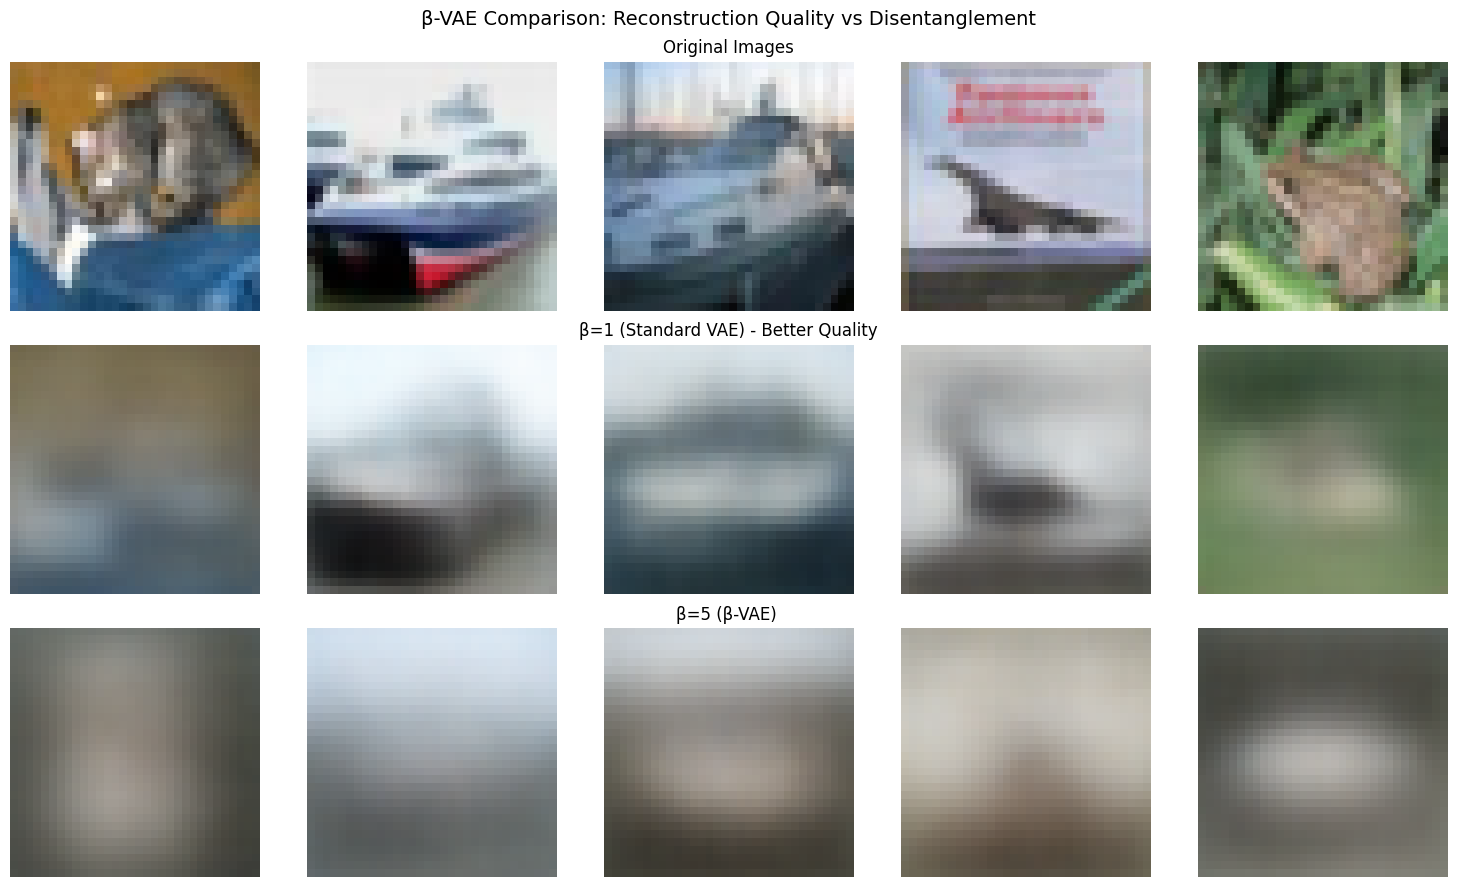

In [ ]:
# =============================================================================
# Step 7: Latent Space Interpolation
# =============================================================================
# Purpose: Test the VAE's ability to generate meaningful intermediate images
# by linearly interpolating between two points in the latent space.
#
# Reason:
# - A well-trained VAE learns a continuous, structured latent space
# - Linear interpolation should produce smooth, realistic transitions
# - This demonstrates the model's "imagination" - generating novel images
#   that were never seen during training
# =============================================================================

def interpolate_latent_space(z1, z2, n_steps=10):
    """
    Generate n_steps interpolated points between z1 and z2 using linear interpolation.

    Formula: z_t = z1 * (1 - t) + z2 * t where t varies from 0 to 1.

    Args:
        z1: Starting latent vector (128-dim)
        z2: Ending latent vector (128-dim)
        n_steps: Number of interpolation steps (default: 10)

    Returns:
        Tensor of shape (n_steps, latent_dim) containing interpolated vectors
    """
    ratios = np.linspace(0, 1, n_steps)  # Create evenly spaced values from 0 to 1
    z_interp = torch.stack([z1 * (1 - r) + z2 * r for r in ratios])
    return z_interp

# Sample two random points from the prior distribution N(0, I)
# These represent two different "concepts" in the latent space
with torch.no_grad():
    z1 = torch.randn(1, latent_dim).to(DEVICE)  # Starting point
    z2 = torch.randn(1, latent_dim).to(DEVICE)  # Ending point

    # Create 10 intermediate latent vectors along the line from z1 to z2
    z_interpolated = interpolate_latent_space(z1.squeeze(), z2.squeeze(), n_steps=10)
    z_interpolated = z_interpolated.to(DEVICE)

    # Decode each latent vector to generate images
    # The decoder "imagines" what image corresponds to each point
    interpolated_images = decoder(z_interpolated)

# Visualize the morphing sequence
# Expected result: Smooth transition showing gradual changes in features
# Poor result: Blurry midpoints or abrupt jumps indicate poor latent space structure
fig, axes = plt.subplots(1, 10, figsize=(20, 2))
fig.suptitle('Latent Space Interpolation: z1 → z2 (Testing VAE\'s Generative Quality)', fontsize=14)

for i, ax in enumerate(axes):
    img = interpolated_images[i].cpu().numpy().transpose(1, 2, 0)
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')
    ax.set_title(f'Step {i+1}')

plt.tight_layout()
plt.show()

# =============================================================================
# Step 8: [Advanced] β-VAE Modification
# =============================================================================
# β-VAE introduces a hyperparameter β to weight the KL Divergence term:
#
# Loss = Reconstruction_Loss + β * KL_Divergence
#
# Trade-offs:
# - β = 1 (Standard VAE): Balanced reconstruction and latent regularity
# - β > 1 (β-VAE): Better disentanglement but blurrier reconstructions
# - β < 1: Sharper images, but entangled features
#
# =============================================================================

def beta_vae_loss_function(x, x_hat, mean, log_var, beta=1.0):
    """
    β-VAE loss function with adjustable KL weight.

    Args:
        x: Original input image
        x_hat: Reconstructed image
        mean: Mean of the latent distribution q(z|x)
        log_var: Log variance of q(z|x)
        beta: Weight for KL divergence (β=1 is standard VAE)

    Returns:
        Total loss = Reconstruction + β * KLD
    """
    # MSE is used for reconstruction loss, suitable for continuous pixel values
    reconstruction_loss = nn.functional.mse_loss(x_hat, x, reduction='sum')

    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    return reconstruction_loss + beta * KLD


def train_beta_vae(beta, epochs=10):
    """Train a β-VAE model with specified β value."""
    # Create fresh model
    enc = Encoder(latent_dim=latent_dim)
    dec = Decoder(latent_dim=latent_dim)
    beta_model = Model(Encoder=enc, Decoder=dec).to(DEVICE)
    opt = Adam(beta_model.parameters(), lr=lr)

    print(f"Training β-VAE with β={beta}...")
    beta_model.train()

    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.to(DEVICE)
            opt.zero_grad()
            x_hat, mean, log_var = beta_model(x)
            loss = beta_vae_loss_function(x, x_hat, mean, log_var, beta=beta)
            total_loss += loss.item()
            loss.backward()
            opt.step()
        # Corrected averaging: Divide by total number of samples for the epoch
        print(f"  Epoch {epoch+1}/{epochs}, Avg Loss: {total_loss / len(train_loader.dataset):.2f}")

    return beta_model


# =============================================================================
# Compare β=1 (Standard) vs β=5 (High disentanglement)
# =============================================================================


print("=" * 60)
print("EXPERIMENT: Comparing β=1 vs β=5")
print("=" * 60)

# Train both models (reduce epochs for faster experimentation)
beta_1_model = train_beta_vae(beta=1, epochs=50)
beta_5_model = train_beta_vae(beta=5, epochs=50)

# Generate samples from both models for comparison
beta_1_model.eval()
beta_5_model.eval()

with torch.no_grad():
    # Get a test batch
    test_x, _ = next(iter(test_loader))
    test_x = test_x.to(DEVICE)

    # Reconstruct with both models
    recon_beta1, _, _ = beta_1_model(test_x)
    recon_beta5, _, _ = beta_5_model(test_x)

# Visualize comparison
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('β-VAE Comparison: Reconstruction Quality vs Disentanglement', fontsize=14)

for i in range(5):
    # Original
    axes[0, i].imshow(np.clip(test_x[i].cpu().numpy().transpose(1, 2, 0), 0, 1))
    axes[0, i].axis('off')
    if i == 2:
        axes[0, i].set_title('Original Images', fontsize=12)

    # β=1 reconstruction
    axes[1, i].imshow(np.clip(recon_beta1[i].cpu().numpy().transpose(1, 2, 0), 0, 1))
    axes[1, i].axis('off')
    if i == 2:
        axes[1, i].set_title('β=1 (Standard VAE) - Better Quality', fontsize=12)

    # β=5 reconstruction
    axes[2, i].imshow(np.clip(recon_beta5[i].cpu().numpy().transpose(1, 2, 0), 0, 1))
    axes[2, i].axis('off')
    if i == 2:
        axes[2, i].set_title('β=5 (β-VAE) ', fontsize=12)

plt.tight_layout()
plt.show()

